In [ ]:
# Path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

In [ ]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics import Ball, CLUBS, PangyaSimulator, Vector3D, Wind

In [ ]:
# Criar simulação

ball = Ball(
    velocity=Vector3D(0.0, 40.0, 220.0),
    rotation_spin=0.0,
    rotation_curve=0.0,
)

club = CLUBS["1W"]
wind = Wind(speed=0, degree=0)

simulator = PangyaSimulator(ball=ball, club=club, wind=wind)

In [ ]:
# Rodar trajetória

trajectory = []

for _ in range(300):
    simulator.step()
    
    trajectory.append(
        {
            "step": simulator.ball.count,
            "x": simulator.ball.position.x,
            "y": simulator.ball.position.y,
            "z": simulator.ball.position.z,
            "velocity_x": simulator.ball.velocity.x,
            "velocity_y": simulator.ball.velocity.y,
            "velocity_z": simulator.ball.velocity.z,
        }
    )

df_trajectory = pd.DataFrame(trajectory)
df_trajectory.head()

,step,x,y,z,velocity_x,velocity_y,velocity_z
0,1,0.0,0.780050,4.365724,0.0,39.002494,218.286202
1,2,0.0,1.540356,8.697723,0.0,38.015292,216.599926
2,3,0.0,2.281119,12.996533,0.0,37.038142,214.940506
3,4,0.0,3.002535,17.262679,0.0,36.070804,213.307294
4,5,0.0,3.704796,21.496672,0.0,35.113044,211.699666


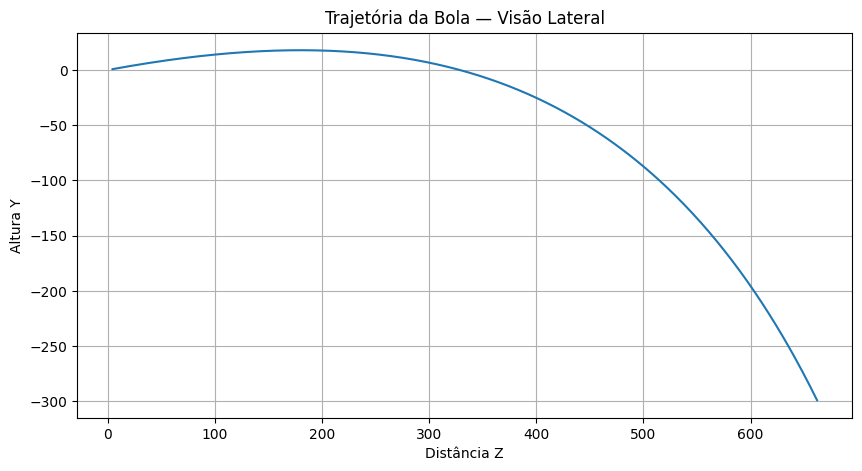

In [ ]:
#Gráfico lateral

plt.figure(figsize=(10, 5))
plt.plot(df_trajectory["z"], df_trajectory["y"])
plt.title("Trajetória da Bola — Visão Lateral")
plt.xlabel("Distância Z")
plt.ylabel("Altura Y")
plt.grid(True)
plt.show()

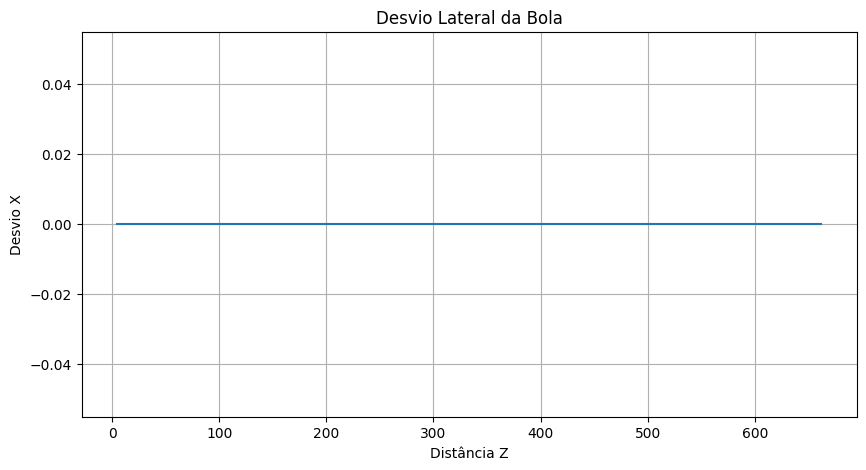

In [ ]:
# Gráfico de desvio

plt.figure(figsize=(10, 5))
plt.plot(df_trajectory["z"], df_trajectory["x"])
plt.title("Desvio Lateral da Bola")
plt.xlabel("Distância Z")
plt.ylabel("Desvio X")
plt.grid(True)
plt.show()